In [64]:
from minio import Minio
import s3fs
import os
import matplotlib.pyplot as plt
import xarray as xr
import pickle
import numpy as np
from sympl import get_constant
import metpy
from metpy.units import units
import matplotlib.pylab as pl
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms
from matplotlib.ticker import ScalarFormatter

fs = s3fs.S3FileSystem(
    client_kwargs={
        "endpoint_url": "http://192.168.1.237:9000"
    },
    key="d0d250b2541ac33f4660",
    secret="2fb32d964768bc94a3c0"
)

output_dir='/home/data/lab_project2/Steve/model_runs/dry_land/scratch/'
base_path = "climt-long-runs/dry-land/regrid-data/"
plot_path = '/home/data/lab_project2/Steve/model_runs/plotting/dl-plots/'
Rd = get_constant('gas_constant_of_dry_air', 'J kg^-1 K^-1')
Cp =\
    get_constant('heat_capacity_of_dry_air_at_constant_pressure',
                 'J kg^-1 K^-1')
g=get_constant('gravitational_acceleration',
                 'm s^-2') 

/tmp/ipykernel_399521/459777030.py:183: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/459777030.py:184: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/459777030.py:185: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/459777030.py:186: UserWarn

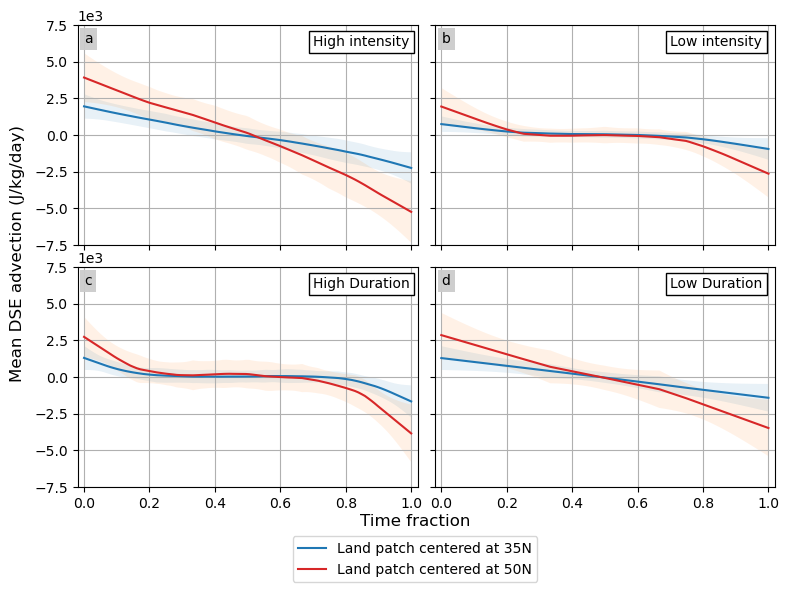

In [66]:
# plot for dse diff

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)

    new_array = np.array(new_array)
    mean = np.mean(new_array, axis=0)
    std = np.std(new_array, axis=0)
    return mean, std, t_common

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])

########################### High intensity ################################

lat_35 = []
dse_master = HI_35
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_35.append(dse_diff)
    
mean, std, t = normalize_time(lat_35) 
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = HI_50
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_50.append(dse_diff)
    
mean, std, t = normalize_time(lat_50) 
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################

lat_35 = []
dse_master = LI_35
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_35.append(dse_diff)
    
mean, std, t = normalize_time(lat_35) 
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = LI_50
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_50.append(dse_diff)
    
mean, std, t = normalize_time(lat_50) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################

lat_35 = []
dse_master = HD_35
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_35.append(dse_diff)
    
mean, std, t = normalize_time(lat_35) 
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = HD_50
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_50.append(dse_diff)
    
mean, std, t = normalize_time(lat_50) 
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################

lat_35 = []
dse_master = LD_35
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_35.append(dse_diff)
    
mean, std, t = normalize_time(lat_35) 
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)

lat_50 = []
dse_master = LD_50
for i in range(len(dse_master['index'])):
    dse_low=dse_master['dse_low'][i]
    dse_diff=(dse_low[1:]-dse_low[:-1])
    lat_50.append(dse_diff)
    
mean, std, t = normalize_time(lat_50) 
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+'5-actual.pdf', bbox_inches='tight')
fig.savefig(plot_path+'5-actual.jpg',dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/4063158.py:159: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/4063158.py:160: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/4063158.py:161: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/4063158.py:162: UserWarning: You

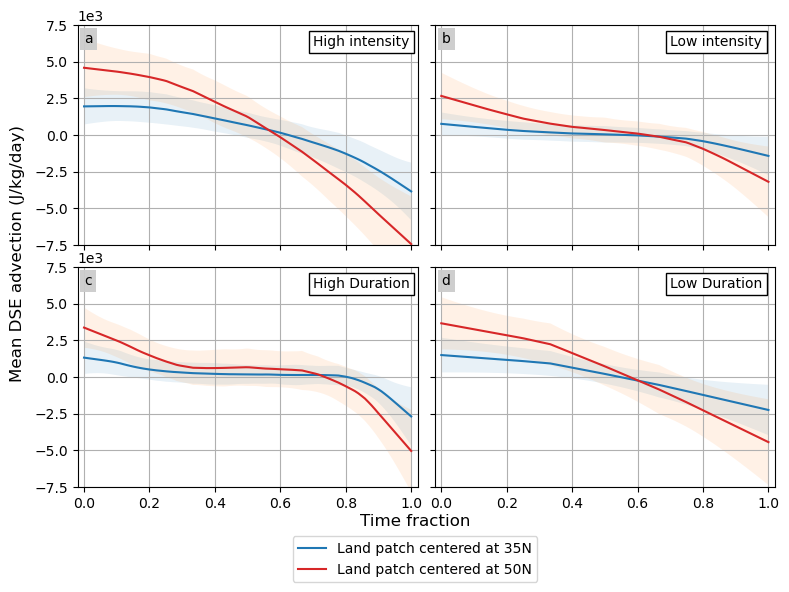

In [67]:
# plotting for dse tendency

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)

    new_array = np.array(new_array)
    mean = np.mean(new_array, axis=0)
    std = np.std(new_array, axis=0)
    return mean, std, t_common

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])

########################### High intensity ################################

lat_35 = []
dse_master = HI_35
lat_35 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_35) 
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = HI_50
lat_50 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_50) 
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################

lat_35 = []
dse_master = LI_35
lat_35 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_35) 
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = LI_50
lat_50 = dse_master['dsetot']

mean, std, t = normalize_time(lat_50) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################

lat_35 = []
dse_master = HD_35
lat_35 = dse_master['dsetot'] 
    
mean, std, t = normalize_time(lat_35) 
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

lat_50 = []
dse_master = HD_50
lat_50 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_50) 
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
lat_35 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_35) 
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)

lat_50 = []
dse_master = LD_50
lat_50 = dse_master['dsetot']
    
mean, std, t = normalize_time(lat_50) 
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+'5-calculated.pdf', bbox_inches='tight')
fig.savefig(plot_path+'5-calculated.jpg',dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/3491559316.py:172: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3491559316.py:173: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3491559316.py:174: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3491559316.py:175: User

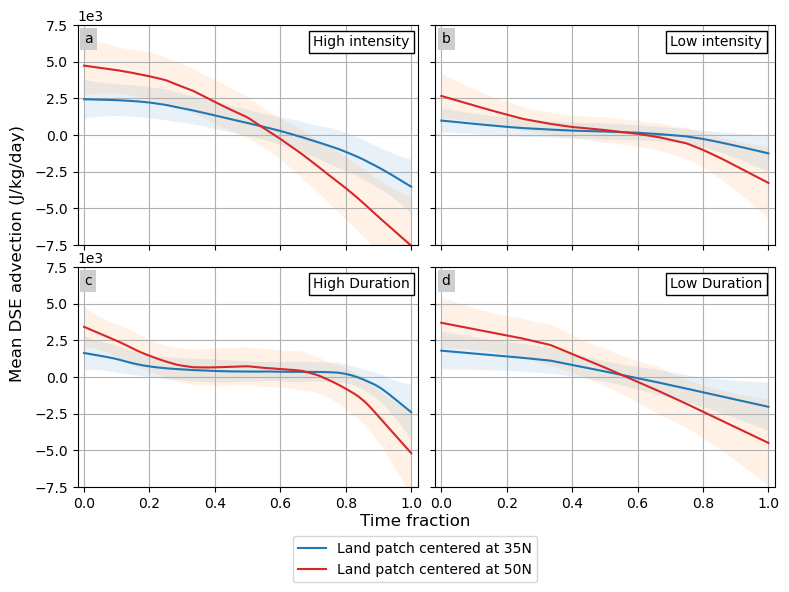

In [68]:
# plot for dse tendency from main contributors
contributors = ['dseyca', 'dseyaa',  'dsexaa', 'dsexac', 'dsez']

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)
        
    return np.array(new_array)

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])

########################### High intensity ################################

dse_master = HI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

dse_master = HI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################


dse_master = LI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = LI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################


dse_master = HD_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = HD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
array= np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)



dse_master = LD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+'5-main.pdf', bbox_inches='tight')
fig.savefig(plot_path+'5-main.jpg',dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/3126624065.py:174: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3126624065.py:175: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3126624065.py:176: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/3126624065.py:177: User

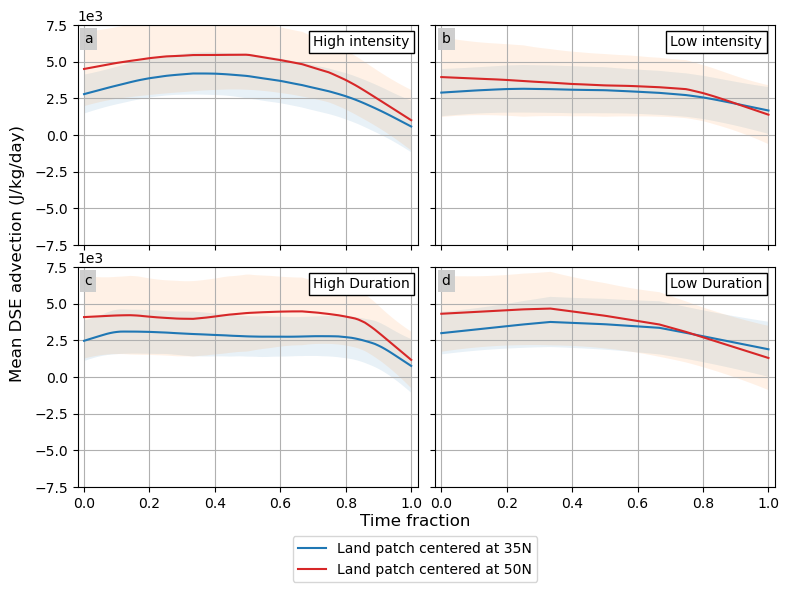

In [69]:
# plot for dse tendency from v'dsbar

contributors = ['dseyca']

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)
        
    return np.array(new_array)

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])


########################### High intensity ################################

dse_master = HI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

dse_master = HI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################


dse_master = LI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = LI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################


dse_master = HD_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = HD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
array= np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)



dse_master = LD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+"5-v'dsbar.pdf", bbox_inches='tight')
fig.savefig(plot_path+"5-v'dsbar.jpg",dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/1864307433.py:174: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1864307433.py:175: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1864307433.py:176: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1864307433.py:177: User

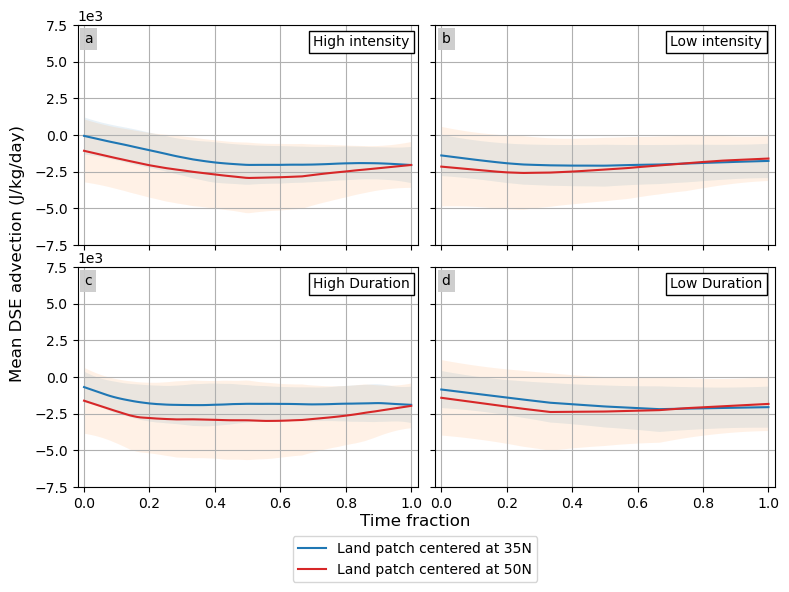

In [70]:
# plot for dse tendency from v'ds'

contributors = ['dseyaa']

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)
        
    return np.array(new_array)

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])


########################### High intensity ################################

dse_master = HI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

dse_master = HI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################


dse_master = LI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = LI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################


dse_master = HD_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = HD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
array= np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)



dse_master = LD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+"5-v'ds'.pdf", bbox_inches='tight')
fig.savefig(plot_path+"5-v'ds'.jpg",dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/81080174.py:174: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/81080174.py:175: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/81080174.py:176: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/81080174.py:177: UserWarning:

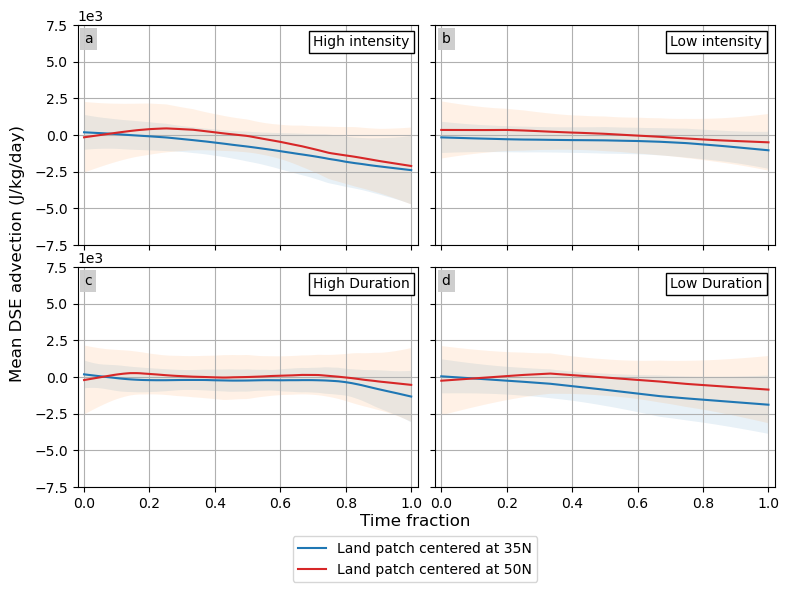

In [71]:
# plot for dse tendency from u'ds'

contributors = ['dsexaa']

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)
        
    return np.array(new_array)

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])


########################### High intensity ################################

dse_master = HI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

dse_master = HI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################


dse_master = LI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = LI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################


dse_master = HD_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = HD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
array= np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)



dse_master = LD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+"5-u'ds'.pdf", bbox_inches='tight')
fig.savefig(plot_path+"5-u'ds'.jpg",dpi=600, bbox_inches='tight')

/tmp/ipykernel_399521/1599815181.py:174: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1599815181.py:175: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1599815181.py:176: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
/tmp/ipykernel_399521/1599815181.py:177: User

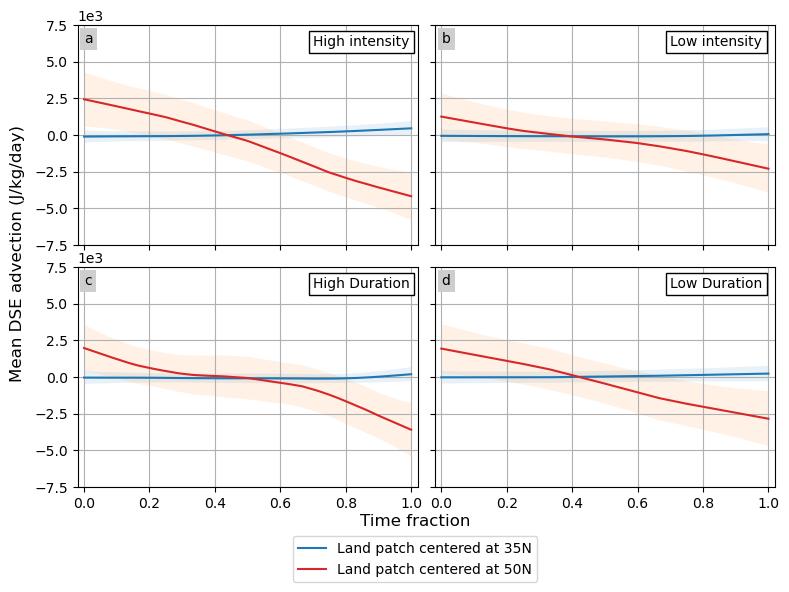

In [72]:
# plot for dse tendency from ubards'

contributors = ['dsexac']

with open(output_dir+'dse_rey_HI_50', 'rb') as f:
    HI_50 = pickle.load(f)

with open(output_dir+'dse_rey_HI_35', 'rb') as f:
    HI_35 = pickle.load(f)

with open(output_dir+'dse_rey_LI_50', 'rb') as f:
    LI_50 = pickle.load(f)

with open(output_dir+'dse_rey_LI_35', 'rb') as f:
    LI_35 = pickle.load(f)
    
with open(output_dir+'dse_rey_HD_50', 'rb') as f:
    HD_50 = pickle.load(f)

with open(output_dir+'dse_rey_HD_35', 'rb') as f:
    HD_35 = pickle.load(f)

with open(output_dir+'dse_rey_LD_50', 'rb') as f:
    LD_50 = pickle.load(f)

with open(output_dir+'dse_rey_LD_35', 'rb') as f:
    LD_35 = pickle.load(f)
    
###########################################################################

def set_label(fig, ax, label):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, label, transform=ax.transAxes + trans,
            fontsize='medium', verticalalignment='top', fontfamily=None,
            bbox=dict(facecolor='0.8', edgecolor='none', pad=3.0, alpha=0.95))

formatter = ScalarFormatter()
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

def normalize_time(var):
    new_array =  []
    t_common = np.linspace(0, 1, 100)
    for i in var:
        t_event = np.linspace(0, 1, len(i))
        interpolated_event = np.interp(t_common, t_event, i)
        new_array.append(interpolated_event)
        
    return np.array(new_array)

#fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
gs = gridspec.GridSpec(2, 2, hspace=0.1, wspace=0.05)
fig=pl.figure(figsize=(9,6))
ax1 = pl.subplot(gs[0, 0])
ax2 = pl.subplot(gs[0, 1]) 
ax3 = pl.subplot(gs[1, 0])
ax4 = pl.subplot(gs[1, 1])


########################### High intensity ################################

dse_master = HI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean)
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')

dse_master = HI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax1.plot(t, mean, c='#d72728')
ax1.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax1.set_ylim(-lim, lim)
ax1.yaxis.set_major_formatter(formatter)
ax1.set_xlim(-0.02,1.02)
ax1.set_xticklabels({})
ax1.grid()
set_label(fig, ax1,'a')

######################### Low intensity ###################################


dse_master = LI_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax2.plot(t, mean)
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = LI_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100) 
ax2.plot(t, mean, c='#d72728')
ax2.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax2.set_ylim(-lim, lim)
ax2.set_xlim(-0.02,1.02)
ax2.set_xticklabels({})
ax2.set_yticklabels({})
ax2.grid()
set_label(fig, ax2,'b')
######################### High duration ###################################


dse_master = HD_35
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean)
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')


dse_master = HD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax3.plot(t, mean, c='#d72728')
ax3.fill_between(t, mean - std, mean + std, alpha=0.1, label='Std Dev')
lim = 0.75e4
ax3.set_ylim(-lim, lim)
ax3.yaxis.set_major_formatter(formatter)
ax3.set_xlim(-0.02,1.02)
ax3.grid()
set_label(fig, ax3,'c')

######################### Low duration ####################################


dse_master = LD_35
array= np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, label='Land patch centered at 35N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)



dse_master = LD_50
array = np.zeros((len(dse_master['dseyaa']),100))
for i in contributors:
    array += normalize_time(dse_master[i])

mean, std, t = np.mean(array, axis=0), np.std(array, axis=0), np.linspace(0,1,100)
ax4.plot(t, mean, c='#d72728', label='Land patch centered at 50N')
ax4.fill_between(t, mean - std, mean + std, alpha=0.1)
lim = 0.75e4
ax4.set_ylim(-lim, lim)
ax4.set_xlim(-0.02,1.02)
ax4.set_yticklabels([])
ax4.grid()
set_label(fig, ax4,'d')

###########################################################################

ax1.annotate("High intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax2.annotate("Low intensity",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax3.annotate("High Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
ax4.annotate("Low Duration",xy=(0.69,0.9), xycoords='axes fraction',textcoords='offset points',size=10,bbox=dict(boxstyle="square", fc='white', ec="black"))
fig.supxlabel("Time fraction", fontsize=12, y = 0.04)
fig.supylabel("Mean DSE advection (J/kg/day)", fontsize=12, x=0.05)

#pl.legend(["Land patch centered at 50N", "Land patch centered at 35N"], bbox_to_anchor=(0.27, -0.13)) 
handles, labels = ax4.get_legend_handles_labels()

# Create a figure-wide legend
fig.legend(handles, labels,
           loc='lower center',
           ncol=1,
           bbox_to_anchor=(0.5, -0.06))

fig.savefig(plot_path+"5-ubards'.pdf", bbox_inches='tight')
fig.savefig(plot_path+"5-ubards'.jpg",dpi=600, bbox_inches='tight')